In [1]:
import os
import sys

sys.path.append("..")

from tqdm.auto import tqdm
from explainerpfn.train import (
    random_dag,
    redirection_sampling_dag,
    random_join,
    plot_dag,
    generate_synthetic_data,
    postprocess_synthetic_data,
    SyntheticDataGenerator,
)

SEED = None

In [2]:
datagen = SyntheticDataGenerator(successor_as_target=[True], random_state=SEED)
if os.path.exists("synthetic_data_v3.pkl"):
    datagen.load_data("synthetic_data_v3.pkl")
else:
    datagen.generate(10, verbose=True)
    datagen.save_data("synthetic_data_v3.pkl")

datagen

  0%|          | 0/10 [00:00<?, ?it/s]

PermutationExplainer explainer: 1365it [02:29,  8.78it/s]
PermutationExplainer explainer: 952it [02:22,  5.96it/s]
ExactExplainer explainer: 1233it [04:15,  4.68it/s]
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
ExactExplainer explainer: 584it [00:24, 12.49it/s]
ExactExplainer explainer: 751it [00:12,  7.50it/s]                         
PermutationExplainer explainer: 1232it [03:16,  5.83it/s]


SyntheticDataGenerator('params_': 10, 'X_': 10, 'y_': 10, 'y_pred_': 10, 'dags_': 10, 'explanations_': 10)

In [3]:
datagen.describe()

,edge_prob,n_train_samples,n_test_samples,n_features,n_dags,successor_as_target,n_nodes
0,0.009719,1236,128,24,1,True,24
1,0.213109,823,128,17,1,True,17
2,0.108927,1922,128,3,2,True,14
3,0.177488,626,128,4,4,True,19
4,0.216322,1104,128,10,4,True,21
5,0.086157,455,128,8,2,True,18
6,0.005430,194,128,4,5,True,27
7,0.147240,367,128,2,2,True,10
8,0.123615,622,128,6,1,True,9
9,0.029215,1103,128,16,1,True,16


In [ ]:
for _ in tqdm(range(10000)):
    datagen.generate(1)
    datagen.save_data("synthetic_data_v3.pkl")
datagen.describe()

In [27]:
import numpy as np
for i in range(len(datagen.X_)):
    exp_std = datagen.explanations_[i].values.std()
    y_std = datagen.y_pred_[i].std()
    print(exp_std, y_std / np.sqrt(datagen.X_[i].shape[1]))

0.06820307235951267 0.09230534704086642
0.14925477959204597 0.10947629626268078
0.18315377315958759 0.18266989073329212
0.08551301065117956 0.10183397085987453
0.15326503828240612 0.1515687217290927
0.08070114457129045 0.11870304160855023
0.1386274644251936 0.17359041939932876
0.1929123278361427 0.20018671766836219
0.137753042382645 0.1538492094201021
0.1066822220576958 0.12170628607099666


# Visualize DAG generation

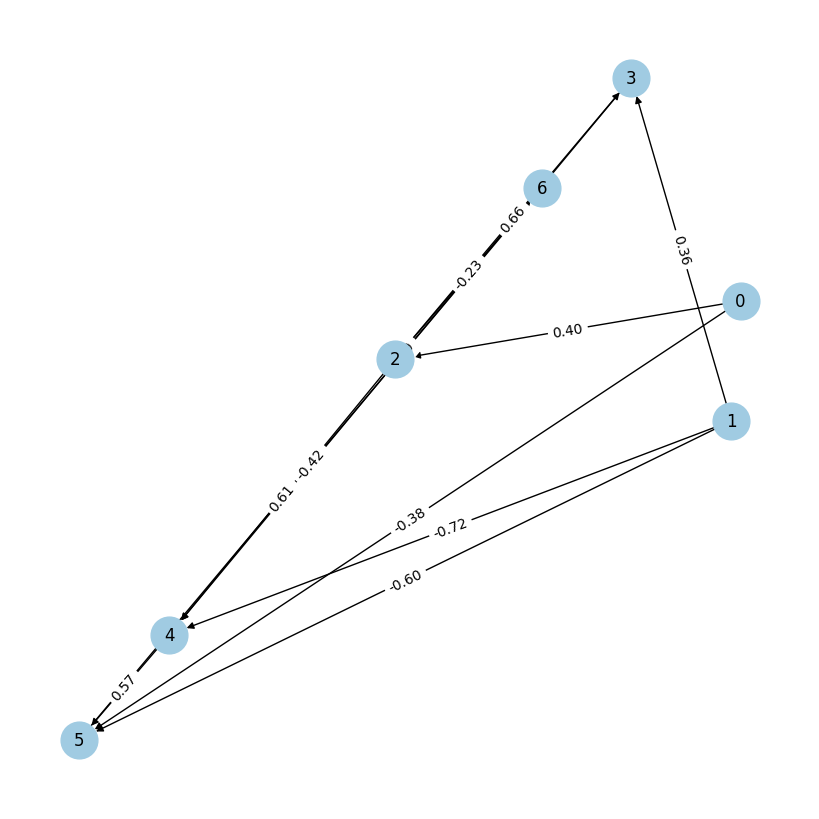

In [3]:
dag_random = random_dag(n_nodes=7, edge_prob=0.5, random_state=SEED)
plot_dag(dag_random)

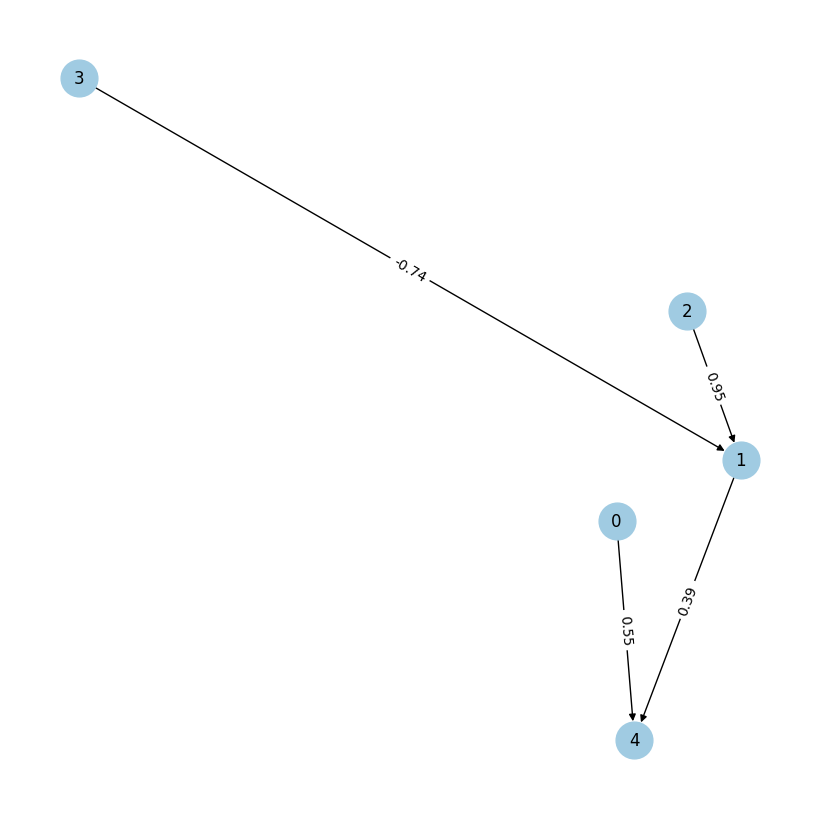

In [25]:
dag_redir = redirection_sampling_dag(n_nodes=5, edge_prob=0.9, random_state=SEED)
plot_dag(dag_redir)

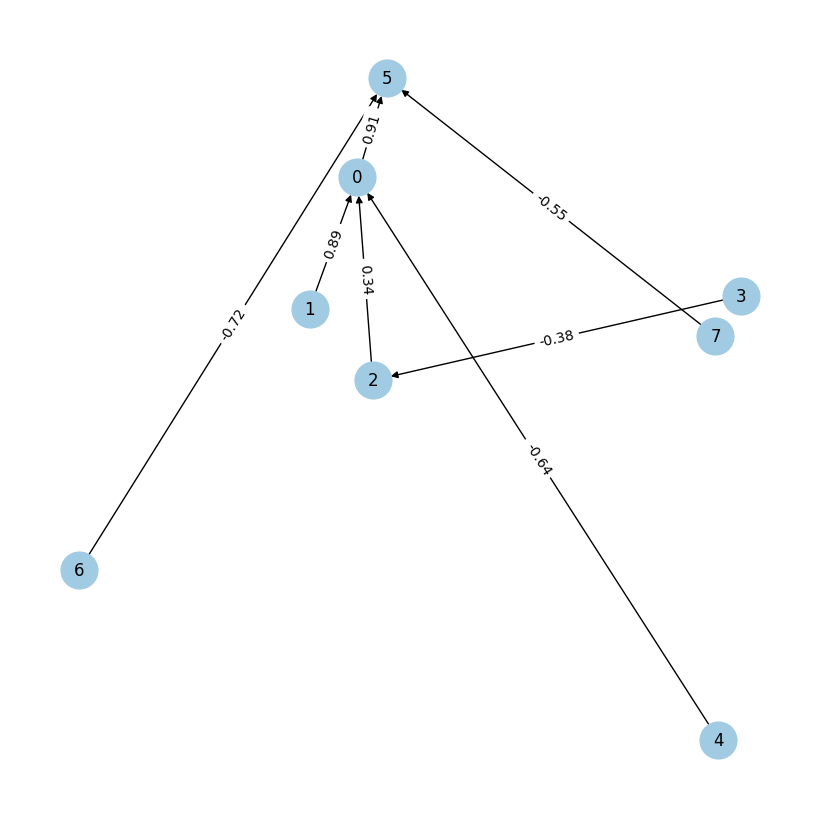

In [5]:
dag1 = redirection_sampling_dag(n_nodes=5, edge_prob=1, random_state=None)
dag2 = redirection_sampling_dag(n_nodes=3, edge_prob=1, random_state=None)
dag = random_join(dag1, dag2, edge_prob=0)
plot_dag(dag)

In [7]:
df = postprocess_synthetic_data(
    *generate_synthetic_data(
        dag,
        init_distr="uniform",
        return_dag_data=True,
        random_state=SEED,
        n_samples=5000,
    ),
    n_features=5,
    target_is_successor=True,
    random_state=None
)
df.corr()

,dep_6,dep_3,dep_2,dep_4,dep_8,target_7
dep_6,1.000000,0.615982,-0.012907,0.002600,-0.039018,0.010242
dep_3,0.615982,1.000000,0.057439,0.402423,-0.041829,0.007662
dep_2,-0.012907,0.057439,1.000000,0.006285,0.006132,0.000148
dep_4,0.002600,0.402423,0.006285,1.000000,-0.015947,0.009017
dep_8,-0.039018,-0.041829,0.006132,-0.015947,1.000000,0.309907
target_7,0.010242,0.007662,0.000148,0.009017,0.309907,1.000000


# Testing Synthetic Data Generator

<Axes: ylabel='Frequency'>

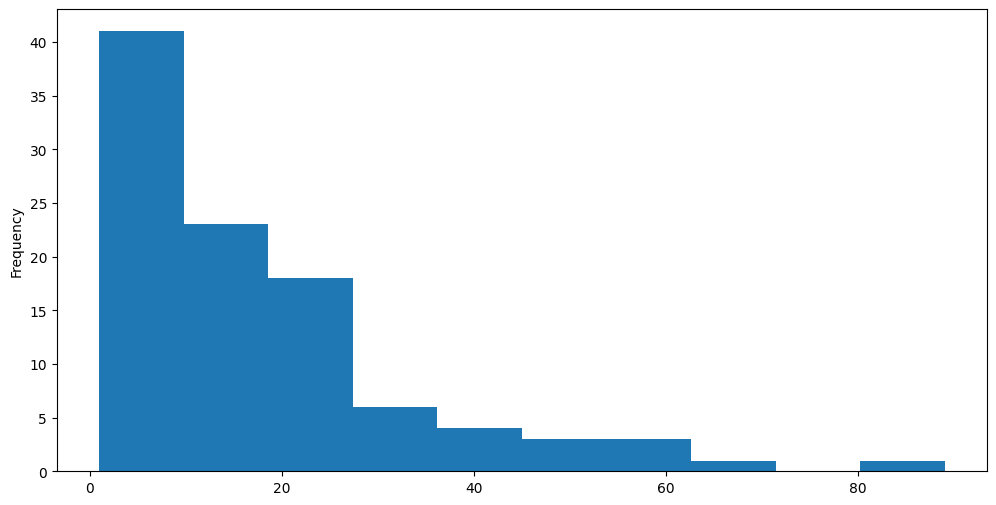

In [ ]:
datagen.describe()["n_features"].plot.hist(figsize=(12, 6))

# Testing random data generation with classifier training

In [ ]:
import numpy as np
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

scores = {
    "baseline": [],
    "scores": [],
    "diff": [],
}

datagen = SyntheticDataGenerator(successor_as_target=[True], random_state=SEED)
datagen.load_data("test.pkl")

for y, y_pred in tqdm(list(zip(datagen.y_, datagen.y_pred_))):

    score = (np.array(y) == (y_pred[:, -1] > 0.5)).mean()
    baseline = max(y.mean(), 1 - y.mean())

    scores["baseline"].append(baseline)
    scores["scores"].append(score)
    scores["diff"].append(score - baseline)

print(
    "Percentage of useless datasets:",
    100
    * sum(
        [(np.array(scores["scores"]) == 1).sum(), (np.array(scores["diff"]) <= 0).sum()]
    )
    / len(scores["scores"]),
    "%",
)

  0%|          | 0/200 [00:00<?, ?it/s]

Baseline: 0.5 | OA: 0.94 | Diff:  0.43 | Shape: (2970, 4)
Baseline: 0.64 | OA: 0.76 | Diff:  0.11 | Shape: (1090, 20)
Baseline: 0.75 | OA: 0.83 | Diff:  0.09 | Shape: (1319, 19)
Baseline: 0.5 | OA: 0.89 | Diff:  0.39 | Shape: (3748, 27)
Baseline: 0.5 | OA: 0.54 | Diff:  0.03 | Shape: (1404, 46)
Baseline: 0.59 | OA: 0.56 | Diff:  -0.03 | Shape: (1660, 22)
Baseline: 0.51 | OA: 0.62 | Diff:  0.11 | Shape: (3104, 29)
Baseline: 0.53 | OA: 0.5 | Diff:  -0.03 | Shape: (1052, 65)
Baseline: 0.52 | OA: 0.98 | Diff:  0.46 | Shape: (2755, 90)
Baseline: 0.53 | OA: 0.58 | Diff:  0.04 | Shape: (623, 5)
Baseline: 0.53 | OA: 0.5 | Diff:  -0.03 | Shape: (2547, 18)
Baseline: 0.5 | OA: 0.52 | Diff:  0.02 | Shape: (3837, 4)
Baseline: 0.53 | OA: 0.5 | Diff:  -0.03 | Shape: (1844, 4)
Baseline: 0.5 | OA: 0.87 | Diff:  0.36 | Shape: (3315, 69)
Baseline: 0.51 | OA: 0.54 | Diff:  0.03 | Shape: (1157, 4)
Baseline: 0.53 | OA: 0.59 | Diff:  0.06 | Shape: (2259, 7)
Baseline: 0.55 | OA: 0.66 | Diff:  0.12 | Shape: (1

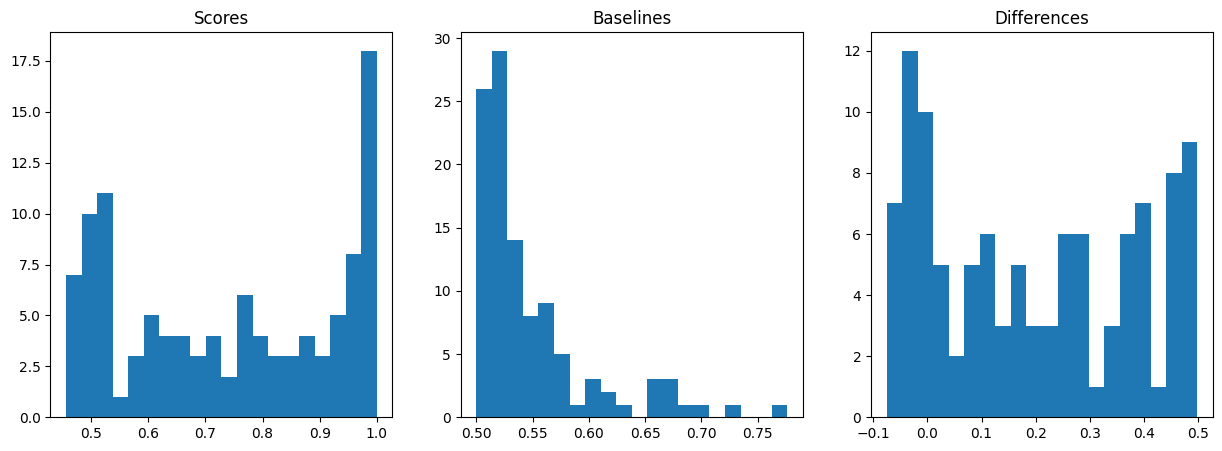

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(scores["scores"], bins=20)
axes[0].set_title("Scores")
axes[1].hist(scores["baseline"], bins=20)
axes[1].set_title("Baselines")
axes[2].hist(scores["diff"], bins=20)
axes[2].set_title("Differences")
plt.show()

# TESTS

In [ ]:
len(scores["scores"])

200

In [ ]:
print(
    "Percentage of useless datasets:",
    100
    * sum(
        [(np.array(scores["scores"]) == 1).sum(), (np.array(scores["diff"]) <= 0).sum()]
    )
    / len(scores["scores"]),
    "%",
)

Percentage of useless datasets: 31.57894736842105 %


In [ ]:
rng = np.random.default_rng(42)
n_features = 5
features = list(rng.choice(df.columns, size=n_features, replace=False))
rng.choice([f for feat in features for f in dag.successors(int(feat.split("_")[-1]))])

np.int64(20)

In [ ]:
list(dag.predecessors(5))

[6, 7, 8, 9, 10, 11, 12]

In [ ]:
columns = list(dag.nodes)
[col for col in df.columns if int(col.split("_")[-1]) in dag]

['dep_0',
 'dep_1',
 'dep_2',
 'dep_3',
 'dep_4',
 'dep_5',
 'dep_6',
 'dep_7',
 'dep_8',
 'dep_9',
 'dep_10',
 'dep_11',
 'dep_12',
 'dep_13',
 'dep_14',
 'dep_15',
 'dep_16',
 'dep_17',
 'dep_18',
 'dep_19',
 'dep_20',
 'dep_21',
 'dep_22',
 'dep_23',
 'dep_24',
 'dep_25',
 'dep_26',
 'dep_27',
 'dep_28',
 'dep_29',
 'dep_30',
 'dep_31',
 'dep_32',
 'dep_33']